In [46]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
checkpoint_path = "/fast/arikreuter/DoPFN_v2/CausalPriorFitting/experiments/FirstTests/checkpoints"

In [48]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [49]:
checkpoint_base = Path(checkpoint_path)

In [71]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (30, 8)

In [84]:
# Define model order and colors
# Order: baseline first, then pairs of (regular, ancestor) for each model
MODEL_ORDER = [
    'baseline', 
    'hardatt', 'ancestor_hardatt',
    'softatt', 'ancestor_softatt',
    'gcn', 'ancestor_gcn',
    'gcn_and_hartatt', 'ancestor_gcn_and_hartatt',
    'gcn_and_softatt', 'ancestor_gcn_and_softatt'
]

MODEL_COLORS = {
    'baseline': '#440154',
    'hardatt': '#31688e',
    'ancestor_hardatt': '#5a9bc4',  # Lighter version of hardatt
    'softatt': '#35b779',
    'ancestor_softatt': '#6dcd9f',  # Lighter version of softatt
    'gcn': '#fde724',
    'ancestor_gcn': '#fee761',  # Lighter version of gcn
    'gcn_and_hartatt': '#90d743',
    'ancestor_gcn_and_hartatt': '#ade577',  # Lighter version
    'gcn_and_softatt': '#21918c',
    'ancestor_gcn_and_softatt': '#46c0b6'  # Lighter version
}

def load_benchmark_results(checkpoint_base, pattern):
    """Load all benchmark JSON files matching the given pattern."""
    results_dict = {}
    
    for ckpt_dir in sorted(checkpoint_base.glob(pattern)):
        json_path = ckpt_dir / "lingaus_final" / "lingaus_benchmark_final.json"
        
        if json_path.exists():
            key = ckpt_dir.name
            with open(json_path, 'r') as f:
                results_dict[key] = json.load(f)
            print(f"Loaded: {key}")
        else:
            print(f"Missing JSON in: {ckpt_dir.name}")
    
    print(f"\nTotal loaded: {len(results_dict)} results")
    return results_dict


def extract_model_name(checkpoint_name):
    """Extract model name from checkpoint directory name."""
    parts = checkpoint_name.split('_')
    model_name_parts = []
    is_ancestor = False
    
    # Handle both "benchmarked" and "ancestor" patterns
    # For benchmarked: lingaus_5node_benchmarked_gcn_16694420.0
    # For ancestor: lingaus_ancestor_5node_gcn_16703127.0
    
    # Check if this is an ancestor model
    if "ancestor" in parts:
        is_ancestor = True
    
    start_collecting = False
    for i, part in enumerate(parts):
        # Start collecting after "benchmarked" keyword
        if part == "benchmarked":
            start_collecting = True
            continue
        
        # For ancestor pattern: start collecting after "Xnode" (e.g., "5node")
        if "node" in part and part.replace("node", "").isdigit():
            start_collecting = True
            continue
        
        # Collect parts that are not PIDs (numbers with dots)
        if start_collecting and not part.replace('.', '').replace('-', '').isdigit():
            model_name_parts.append(part)
    
    model_name = '_'.join(model_name_parts) if model_name_parts else 'unknown'
    
    # Add "ancestor_" prefix if this is an ancestor model
    if is_ancestor and model_name != 'unknown':
        model_name = f'ancestor_{model_name}'
    
    return model_name


def create_dataframe(results_dict):
    """Convert results dictionary to pandas DataFrame."""
    data_rows = []
    
    for checkpoint_name, result in results_dict.items():
        model_name = extract_model_name(checkpoint_name)
        
        # Iterate through each node count
        for node_count, node_data in result.items():
            row = {
                'model': model_name,
                'node_count': int(node_count),
            }
            
            # Extract metrics (mse, r2, nll, etc.)
            for metric_name, metric_values in node_data.items():
                if metric_name != 'metadata' and isinstance(metric_values, dict):
                    for stat_name, stat_value in metric_values.items():
                        if isinstance(stat_value, (int, float)):
                            row[f"{metric_name}_{stat_name}"] = stat_value
            
            data_rows.append(row)
    
    df = pd.DataFrame(data_rows)
    
    # Drop rows where key metrics are NaN (incomplete runs)
    print(f"Original shape: {df.shape}")
    df = df.dropna(subset=['mse_mean', 'r2_mean', 'nll_mean'])
    print(f"After dropping NaN rows: {df.shape}")
    
    # Apply consistent model order
    df['model'] = pd.Categorical(df['model'], categories=MODEL_ORDER, ordered=True)
    
    return df


def plot_metrics_vs_nodes(df, title_suffix=""):
    """Create line plots showing metrics across node counts."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    metrics_to_plot = ['mse', 'r2', 'nll']
    metric_titles = ['Mean Squared Error (MSE)', 'R² Score', 'Negative Log Likelihood (NLL)']
    
    for idx, (metric, title) in enumerate(zip(metrics_to_plot, metric_titles)):
        ax = axes[idx]
        
        # Plot each model
        for model in sorted(df['model'].unique()):
            model_data = df[df['model'] == model].sort_values('node_count')
            
            if f'{metric}_mean' in model_data.columns:
                x = model_data['node_count']
                y = model_data[f'{metric}_mean']
                
                # Plot with confidence intervals
                if f'{metric}_mean_ci_lower' in model_data.columns:
                    y_lower = model_data[f'{metric}_mean_ci_lower']
                    y_upper = model_data[f'{metric}_mean_ci_upper']
                    ax.fill_between(x, y_lower, y_upper, alpha=0.2)
                
                ax.plot(x, y, marker='o', linewidth=2, label=model, markersize=8,
                       color=MODEL_COLORS.get(str(model), '#808080'))
        
        ax.set_xlabel('Number of Nodes', fontsize=12, fontweight='bold')
        ax.set_ylabel(title, fontsize=12, fontweight='bold')
        ax.set_title(f'{title} vs Node Count', fontsize=14, fontweight='bold')
        ax.legend(loc='best', frameon=True, shadow=True)
        ax.grid(True, alpha=0.3)
    
    if title_suffix:
        plt.suptitle(title_suffix, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_bar_comparison(df, node_counts_to_compare=None, title_suffix=""):
    """Create bar charts comparing models at specific node counts."""
    if node_counts_to_compare is None:
        node_counts_to_compare = sorted(df['node_count'].unique())
    
    metrics_to_plot = ['mse', 'r2', 'nll']
    metric_titles = ['MSE', 'R²', 'NLL']
    
    fig, axes = plt.subplots(len(metrics_to_plot), len(node_counts_to_compare), 
                            figsize=(40, 12))
    
    for metric_idx, (metric, metric_title) in enumerate(zip(metrics_to_plot, metric_titles)):
        for node_idx, node_count in enumerate(node_counts_to_compare):
            ax = axes[metric_idx, node_idx]
            
            # Filter data for this node count
            node_data = df[df['node_count'] == node_count].copy()
            
            if len(node_data) == 0:
                ax.text(0.5, 0.5, f'No data', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{node_count} Nodes')
                continue
            
            # Sort by model order
            node_data = node_data.sort_values('model')
            
            models = node_data['model'].values
            x_pos = np.arange(len(models))
            
            # Plot metric with 95% CI error bars
            metric_col = f'{metric}_mean'
            if metric_col in node_data.columns:
                metric_vals = node_data[metric_col].values
                
                # Calculate error bars from 95% CI
                ci_lower_col = f'{metric}_mean_ci_lower'
                ci_upper_col = f'{metric}_mean_ci_upper'
                
                if ci_lower_col in node_data.columns and ci_upper_col in node_data.columns:
                    ci_lower = node_data[ci_lower_col].values
                    ci_upper = node_data[ci_upper_col].values
                    yerr_lower = metric_vals - ci_lower
                    yerr_upper = ci_upper - metric_vals
                    yerr = np.array([yerr_lower, yerr_upper])
                else:
                    yerr = None
                
                #standard_error = node_data.get(f'{metric}_std', pd.Series([0]*len(node_data))).values / np.sqrt(len(node_data))
                #yerr = standard_error

                bars = ax.bar(x_pos, metric_vals, yerr=yerr, capsize=4, alpha=0.7, 
                            edgecolor='black', linewidth=1.5)
                
                # Color bars consistently
                for bar, model in zip(bars, models):
                    bar.set_color(MODEL_COLORS.get(str(model), '#808080'))
                
                # Add value labels
                for i, val in enumerate(metric_vals):
                    if yerr is not None:
                        label_y = val + yerr[1][i]
                    else:
                        label_y = val
                    ax.text(i, label_y, f'{val:.4f}', ha='center', va='bottom', fontsize=8)
            
            ax.set_xticks(x_pos)
            ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
            
            # Add horizontal line at baseline level
            baseline_data = node_data[node_data['model'] == 'baseline']
            if len(baseline_data) > 0 and metric_col in baseline_data.columns:
                baseline_val = baseline_data[metric_col].values[0]
                ax.axhline(y=baseline_val, color='gray', linestyle='--', linewidth=2, alpha=0.7, zorder=0)
            
            if node_idx == 0:
                ax.set_ylabel(metric_title, fontsize=11, fontweight='bold')
            
            if metric_idx == 0:
                ax.set_title(f'{node_count} Nodes', fontsize=11, fontweight='bold')
            
            ax.grid(axis='y', alpha=0.3)
    
    main_title = 'Model Performance Comparison Across Node Counts (95% CI)'
    if title_suffix:
        main_title = f'{main_title} - {title_suffix}'
    plt.suptitle(main_title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()


def plot_heatmaps(df, title_suffix=""):
    """Create heatmaps showing model performance across metrics and node counts."""
    if 'mse_mean' not in df.columns:
        print("No metrics found for heatmap")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # MSE heatmap
    pivot_mse = df.pivot(index='model', columns='node_count', values='mse_mean')
    sns.heatmap(pivot_mse, annot=True, fmt='.4f', cmap='RdYlGn_r', ax=axes[0], 
                cbar_kws={'label': 'MSE'}, linewidths=0.5)
    axes[0].set_title('MSE by Model and Node Count', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Node Count', fontsize=12)
    axes[0].set_ylabel('Model', fontsize=12)
    
    # R2 heatmap
    if 'r2_mean' in df.columns:
        pivot_r2 = df.pivot(index='model', columns='node_count', values='r2_mean')
        sns.heatmap(pivot_r2, annot=True, fmt='.4f', cmap='RdYlGn', ax=axes[1], 
                    cbar_kws={'label': 'R²'}, linewidths=0.5)
        axes[1].set_title('R² by Model and Node Count', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Node Count', fontsize=12)
        axes[1].set_ylabel('Model', fontsize=12)
    
    # NLL heatmap
    if 'nll_mean' in df.columns:
        pivot_nll = df.pivot(index='model', columns='node_count', values='nll_mean')
        sns.heatmap(pivot_nll, annot=True, fmt='.4f', cmap='RdYlGn_r', ax=axes[2], 
                    cbar_kws={'label': 'NLL'}, linewidths=0.5)
        axes[2].set_title('NLL by Model and Node Count', fontsize=14, fontweight='bold')
        axes[2].set_xlabel('Node Count', fontsize=12)
        axes[2].set_ylabel('Model', fontsize=12)
    
    if title_suffix:
        plt.suptitle(title_suffix, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def print_summary_statistics(df, title_suffix=""):
    """Print summary statistics table."""
    print("="*80)
    if title_suffix:
        print(f"SUMMARY STATISTICS BY MODEL - {title_suffix}")
    else:
        print("SUMMARY STATISTICS BY MODEL")
    print("="*80)
    
    for model in sorted(df['model'].unique()):
        model_data = df[df['model'] == model]
        print(f"\n{str(model).upper()}")
        print("-"*80)
        
        if 'mse_mean' in model_data.columns:
            print(f"MSE   - Mean: {model_data['mse_mean'].mean():.6f} ± {model_data['mse_mean'].std():.6f}")
        if 'r2_mean' in model_data.columns:
            print(f"R²    - Mean: {model_data['r2_mean'].mean():.6f} ± {model_data['r2_mean'].std():.6f}")
        if 'nll_mean' in model_data.columns:
            print(f"NLL   - Mean: {model_data['nll_mean'].mean():.6f} ± {model_data['nll_mean'].std():.6f}")
    
    print("\n" + "="*80)


def analyze_benchmark_results(checkpoint_base, pattern, node_counts_to_compare=None, title_suffix=""):
    """Main function to analyze benchmark results for a given pattern."""
    print(f"\n{'='*80}")
    print(f"Loading results for pattern: {pattern}")
    print(f"{'='*80}\n")
    
    # Load and process data
    results_dict = load_benchmark_results(checkpoint_base, pattern)
    
    if not results_dict:
        print(f"No results found for pattern: {pattern}")
        return None
    
    df = create_dataframe(results_dict)
    
    print(f"\nModels: {sorted(df['model'].unique())}")
    print(f"Node counts: {sorted(df['node_count'].unique())}")
    
    # Generate all plots
    #plot_metrics_vs_nodes(df, title_suffix)
    plot_bar_comparison(df, node_counts_to_compare, title_suffix)
    #plot_heatmaps(df, title_suffix)
    print_summary_statistics(df, title_suffix)
    
    return df

print("Analysis functions defined successfully!")


Analysis functions defined successfully!


# Five-node-models

Missing JSON in: lingaus_5node_benchmarked_baseline_16693340.0
Loaded: lingaus_5node_benchmarked_baseline_16694417.0
Missing JSON in: lingaus_5node_benchmarked_baseline_16694659.0
Missing JSON in: lingaus_5node_benchmarked_baseline_16694660.0
Missing JSON in: lingaus_5node_benchmarked_baseline_16694661.0
Missing JSON in: lingaus_5node_benchmarked_baseline_16694682.0
Missing JSON in: lingaus_5node_benchmarked_baseline_16694684.0
Missing JSON in: lingaus_5node_benchmarked_baseline_16694688.0
Missing JSON in: lingaus_5node_benchmarked_baseline_16694695.0
Missing JSON in: lingaus_5node_benchmarked_baseline_16694696.0
Missing JSON in: lingaus_5node_benchmarked_baseline_16694698.0
Loaded: lingaus_5node_benchmarked_baseline_16694705.0
Missing JSON in: lingaus_5node_benchmarked_gcn_16693343.0
Missing JSON in: lingaus_5node_benchmarked_gcn_16694413.0
Loaded: lingaus_5node_benchmarked_gcn_16694420.0
Missing JSON in: lingaus_5node_benchmarked_gcn_and_hartatt_16693341.0
Loaded: lingaus_5node_bench

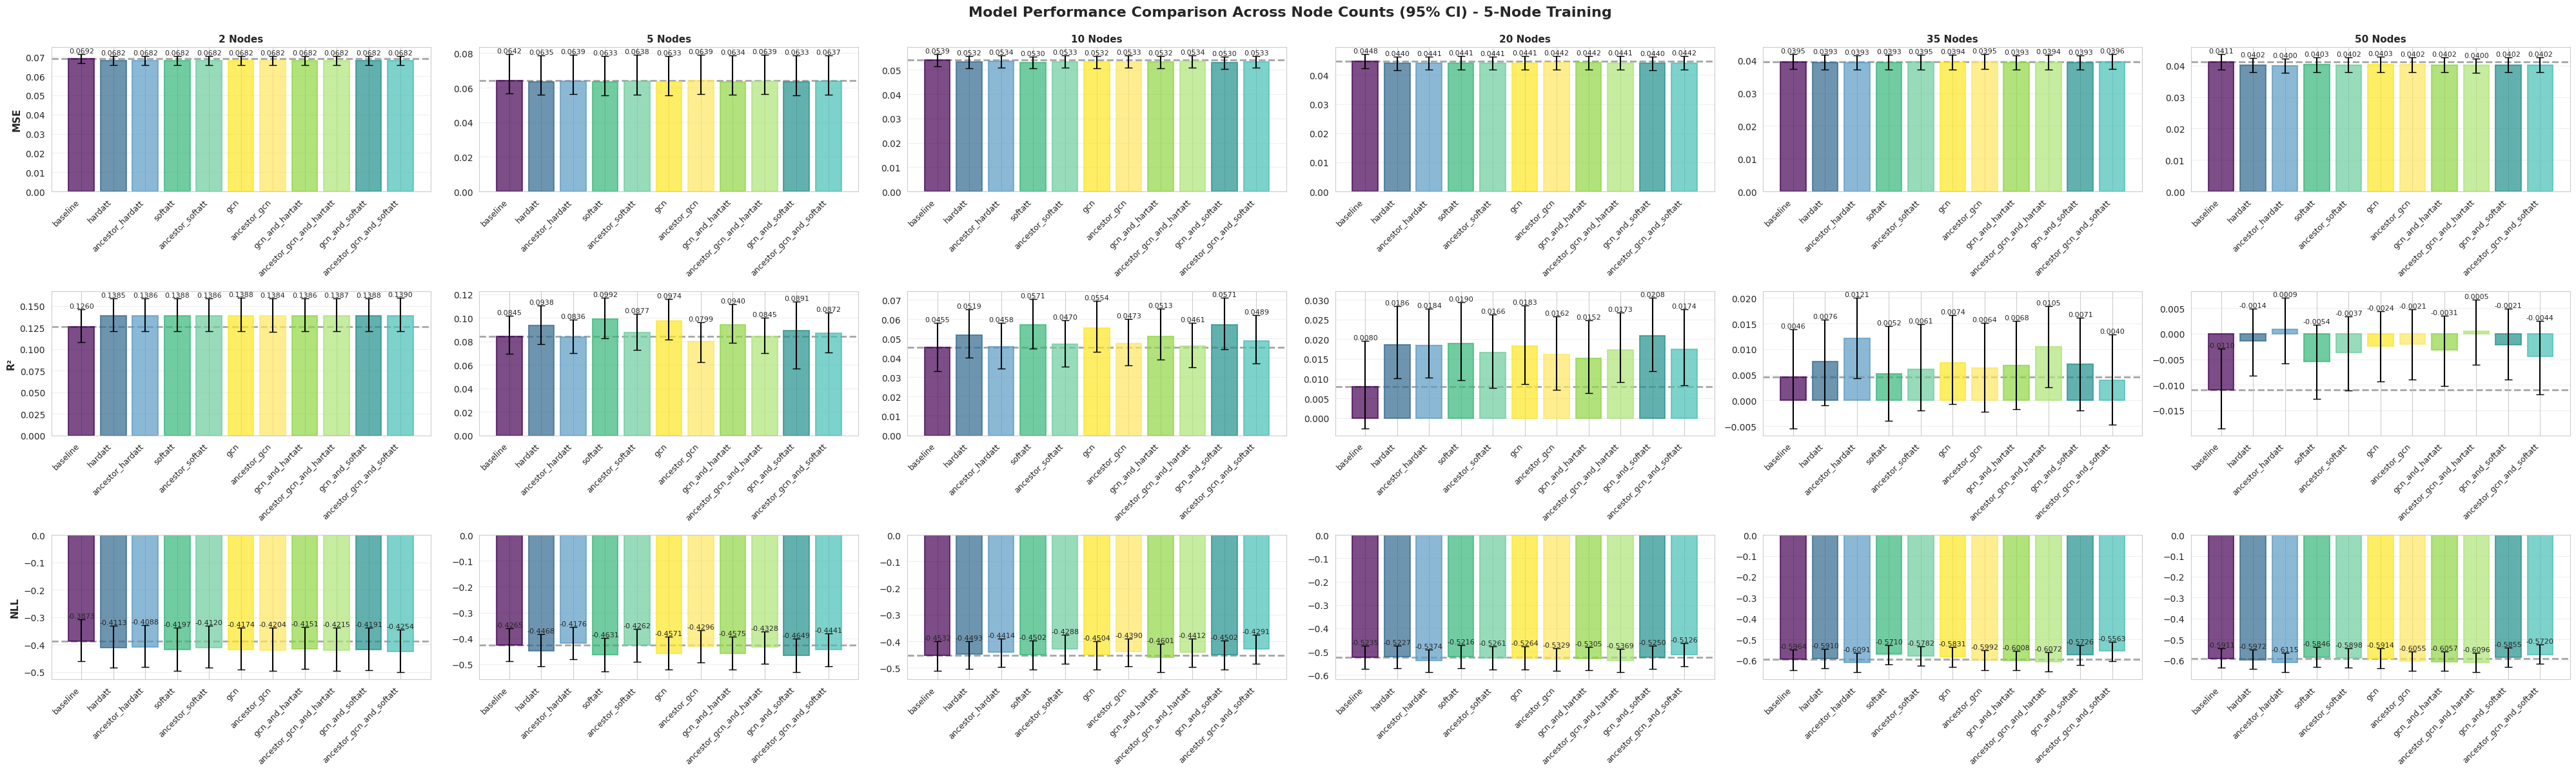

SUMMARY STATISTICS BY MODEL - 5-Node Training

ANCESTOR_GCN
--------------------------------------------------------------------------------
MSE   - Mean: 0.051574 ± 0.012327
R²    - Mean: 0.047688 ± 0.053730
NLL   - Mean: -0.504449 ± 0.085970

ANCESTOR_GCN_AND_HARTATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.051498 ± 0.012395
R²    - Mean: 0.049572 ± 0.053234
NLL   - Mean: -0.508195 ± 0.087874

ANCESTOR_GCN_AND_SOFTATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.051522 ± 0.012261
R²    - Mean: 0.048672 ± 0.055554
NLL   - Mean: -0.489924 ± 0.065752

ANCESTOR_HARDATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.051494 ± 0.012423
R²    - Mean: 0.049894 ± 0.052607
NLL   - Mean: -0.504311 ± 0.093975

ANCESTOR_SOFTATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.051517 ± 0.012335
R

In [85]:

# Analyze 5-node benchmarked results (including both regular and ancestor models)
# Load regular benchmarked results
pattern_5node_regular = "lingaus_5node_benchmarked_*"
results_dict_regular = load_benchmark_results(checkpoint_base, pattern_5node_regular)

# Load ancestor results
pattern_5node_ancestor = "lingaus_ancestor_5node_*"
results_dict_ancestor = load_benchmark_results(checkpoint_base, pattern_5node_ancestor)

# Combine both dictionaries
results_dict_combined = {**results_dict_regular, **results_dict_ancestor}

print(f"\n{'='*80}")
print(f"Combined: {len(results_dict_combined)} total results (regular + ancestor)")
print(f"{'='*80}\n")

# Create dataframe from combined results
df_5node = create_dataframe(results_dict_combined)
print(f"\nModels: {sorted(df_5node['model'].unique())}")
print(f"Node counts: {sorted(df_5node['node_count'].unique())}")

# Generate plots
plot_bar_comparison(df_5node, node_counts_to_compare=[2, 5, 10, 20, 35, 50], title_suffix="5-Node Training")
print_summary_statistics(df_5node, title_suffix="5-Node Training")

# Twenty-node-models

Missing JSON in: lingaus_20node_benchmarked_baseline_16693346.0
Missing JSON in: lingaus_20node_benchmarked_baseline_16694423.0
Loaded: lingaus_20node_benchmarked_baseline_16694706.0
Missing JSON in: lingaus_20node_benchmarked_gcn_16693349.0
Loaded: lingaus_20node_benchmarked_gcn_16694426.0
Missing JSON in: lingaus_20node_benchmarked_gcn_and_hartatt_16693347.0
Loaded: lingaus_20node_benchmarked_gcn_and_hartatt_16694424.0
Missing JSON in: lingaus_20node_benchmarked_gcn_and_softatt_16693348.0
Loaded: lingaus_20node_benchmarked_gcn_and_softatt_16694425.0
Missing JSON in: lingaus_20node_benchmarked_hardatt_16693350.0
Loaded: lingaus_20node_benchmarked_hardatt_16694427.0
Missing JSON in: lingaus_20node_benchmarked_softatt_16693351.0
Loaded: lingaus_20node_benchmarked_softatt_16694428.0

Total loaded: 6 results
Loaded: lingaus_ancestor_20node_gcn_16703133.0
Loaded: lingaus_ancestor_20node_gcn_and_hartatt_16703131.0
Missing JSON in: lingaus_ancestor_20node_gcn_and_softatt_16703132.0
Loaded: l

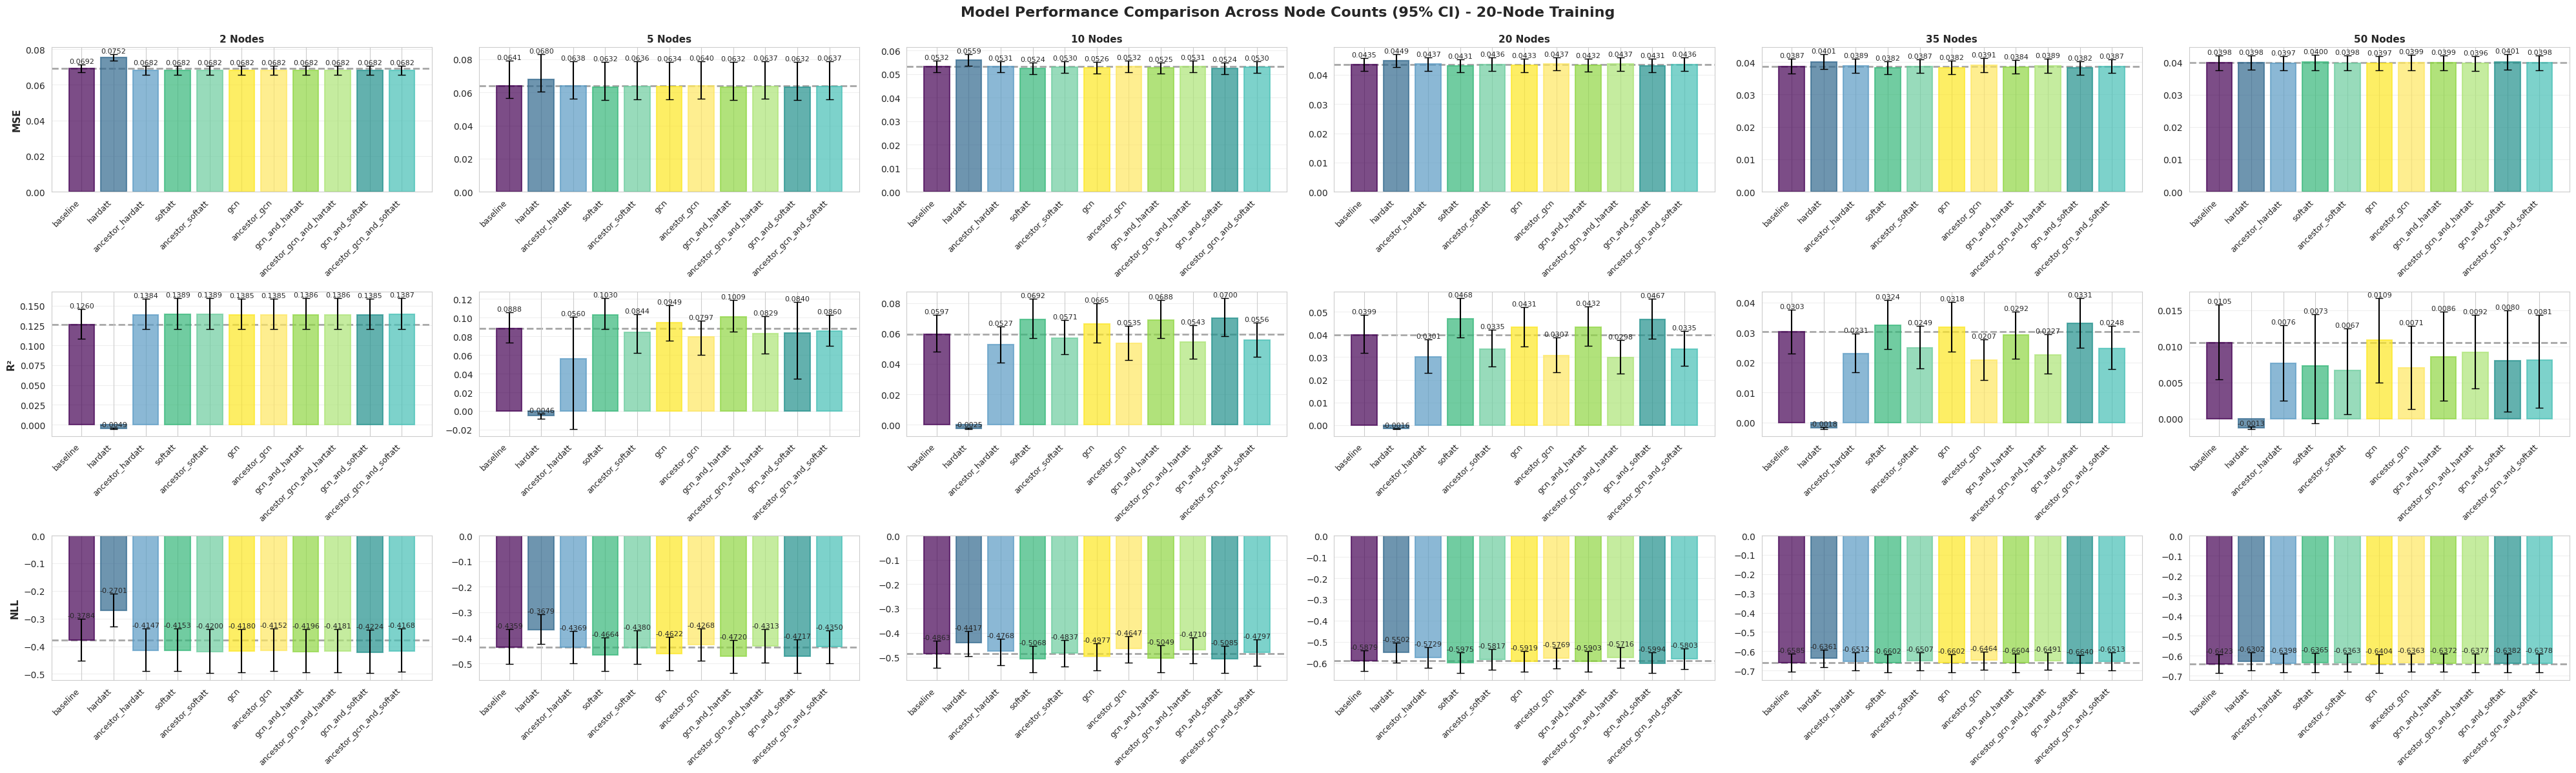

SUMMARY STATISTICS BY MODEL - 20-Node Training

ANCESTOR_GCN
--------------------------------------------------------------------------------
MSE   - Mean: 0.051347 ± 0.012559
R²    - Mean: 0.055032 ± 0.048267
NLL   - Mean: -0.527709 ± 0.105005

ANCESTOR_GCN_AND_HARTATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.051197 ± 0.012580
R²    - Mean: 0.056250 ± 0.048055
NLL   - Mean: -0.529810 ± 0.103218

ANCESTOR_GCN_AND_SOFTATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.051174 ± 0.012572
R²    - Mean: 0.057783 ± 0.047945
NLL   - Mean: -0.533493 ± 0.103132

ANCESTOR_HARDATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.051221 ± 0.012585
R²    - Mean: 0.051311 ± 0.046399
NLL   - Mean: -0.532046 ± 0.103286

ANCESTOR_SOFTATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.051159 ± 0.012571


In [86]:
# Analyze 20-node benchmarked results (including both regular and ancestor models)
# Load regular benchmarked results
pattern_20node_regular = "lingaus_20node_benchmarked_*"
results_dict_regular = load_benchmark_results(checkpoint_base, pattern_20node_regular)

# Load ancestor results
pattern_20node_ancestor = "lingaus_ancestor_20node_*"
results_dict_ancestor = load_benchmark_results(checkpoint_base, pattern_20node_ancestor)

# Combine both dictionaries
results_dict_combined = {**results_dict_regular, **results_dict_ancestor}

print(f"\n{'='*80}")
print(f"Combined: {len(results_dict_combined)} total results (regular + ancestor)")
print(f"{'='*80}\n")

# Create dataframe from combined results
df_20node = create_dataframe(results_dict_combined)
print(f"\nModels: {sorted(df_20node['model'].unique())}")
print(f"Node counts: {sorted(df_20node['node_count'].unique())}")

# Generate plots
plot_bar_comparison(df_20node, node_counts_to_compare=[2, 5, 10, 20, 35, 50], title_suffix="20-Node Training")
print_summary_statistics(df_20node, title_suffix="20-Node Training")


# Fifty-node-models

Missing JSON in: lingaus_50node_benchmarked_baseline_16693352.0
Missing JSON in: lingaus_50node_benchmarked_baseline_16694429.0
Loaded: lingaus_50node_benchmarked_baseline_16694707.0
Missing JSON in: lingaus_50node_benchmarked_gcn_16693355.0
Loaded: lingaus_50node_benchmarked_gcn_16694432.0
Missing JSON in: lingaus_50node_benchmarked_gcn_and_hartatt_16693353.0
Loaded: lingaus_50node_benchmarked_gcn_and_hartatt_16694430.0
Missing JSON in: lingaus_50node_benchmarked_gcn_and_softatt_16693354.0
Loaded: lingaus_50node_benchmarked_gcn_and_softatt_16694431.0
Missing JSON in: lingaus_50node_benchmarked_hardatt_16693356.0
Loaded: lingaus_50node_benchmarked_hardatt_16694433.0
Missing JSON in: lingaus_50node_benchmarked_softatt_16693336.0
Missing JSON in: lingaus_50node_benchmarked_softatt_16693357.0
Loaded: lingaus_50node_benchmarked_softatt_16694434.0

Total loaded: 6 results
Loaded: lingaus_ancestor_50node_gcn_16703138.0
Missing JSON in: lingaus_ancestor_50node_gcn_and_hartatt_16703136.0
Missi

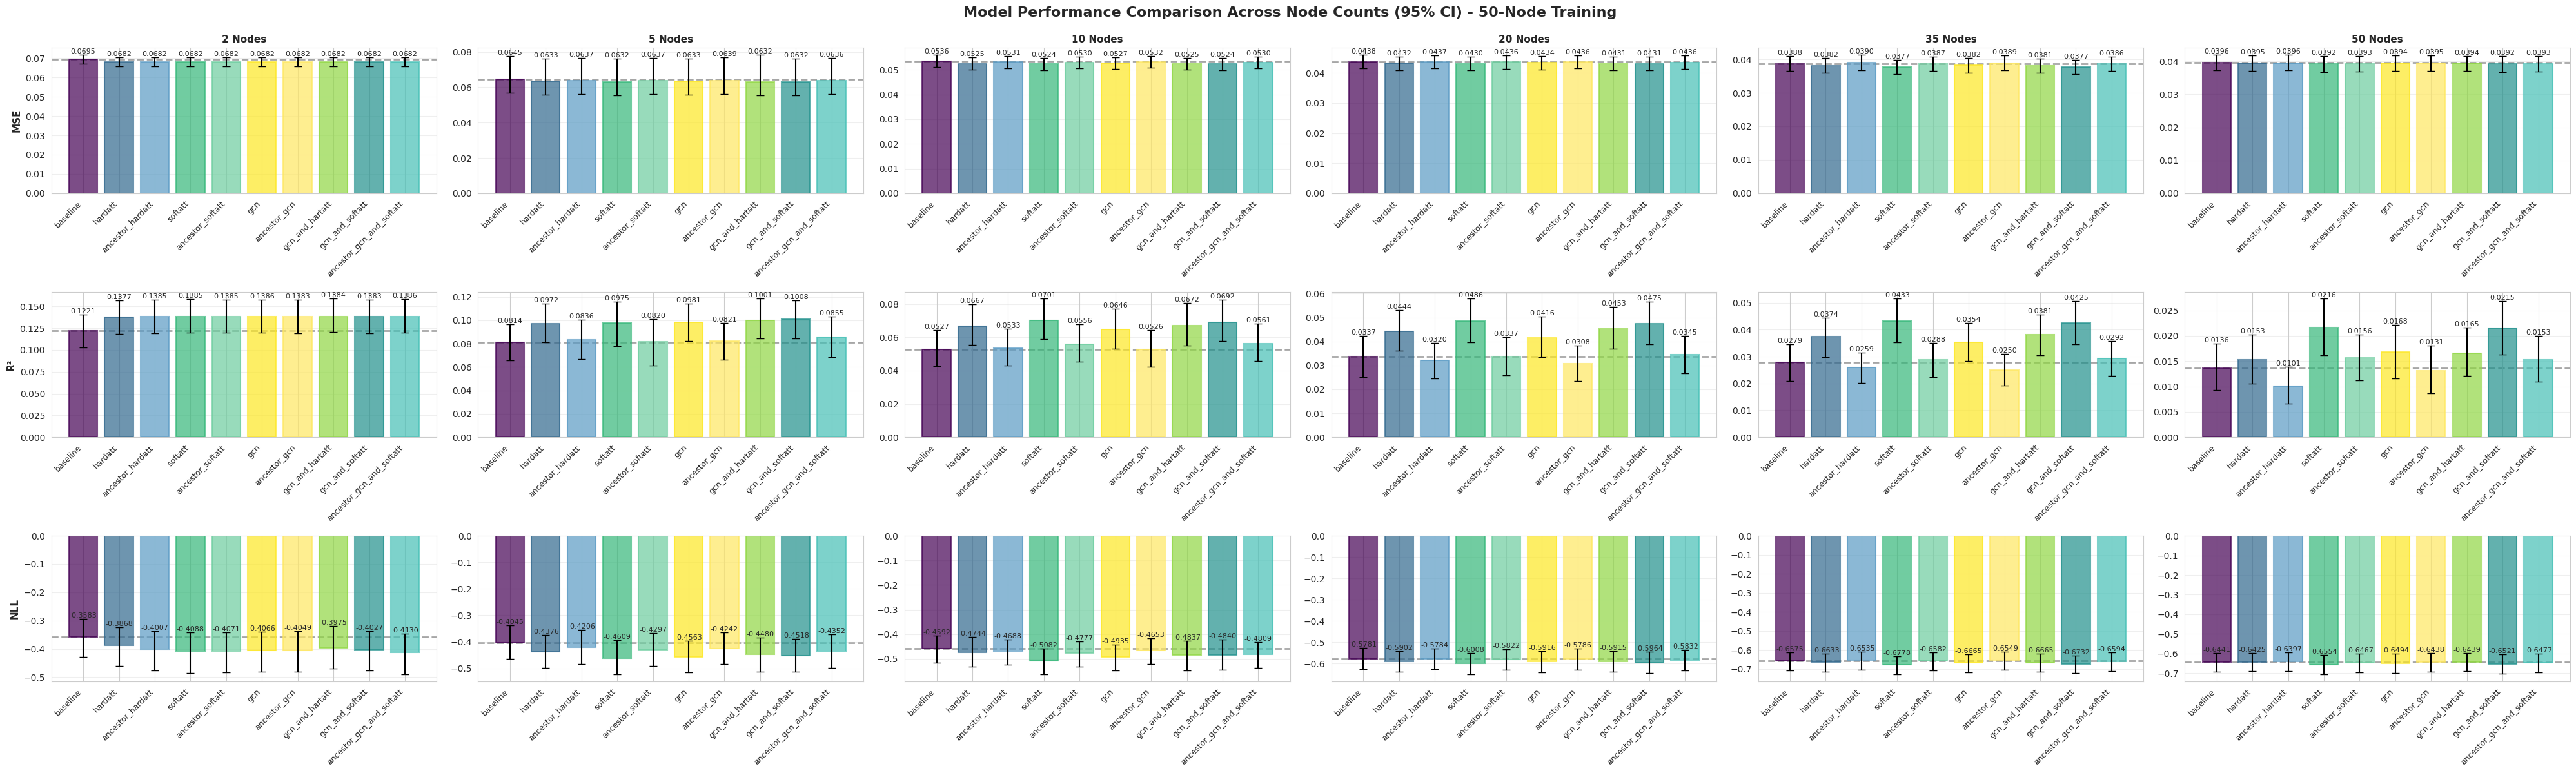

SUMMARY STATISTICS BY MODEL - 50-Node Training

ANCESTOR_GCN
--------------------------------------------------------------------------------
MSE   - Mean: 0.051229 ± 0.012658
R²    - Mean: 0.056990 ± 0.046670
NLL   - Mean: -0.528629 ± 0.111311

ANCESTOR_GCN_AND_SOFTATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.051060 ± 0.012685
R²    - Mean: 0.059862 ± 0.045715
NLL   - Mean: -0.536580 ± 0.107932

ANCESTOR_HARDATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.051206 ± 0.012574
R²    - Mean: 0.057225 ± 0.047224
NLL   - Mean: -0.526941 ± 0.111352

ANCESTOR_SOFTATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.051073 ± 0.012680
R²    - Mean: 0.059029 ± 0.045381
NLL   - Mean: -0.533591 ± 0.110086

BASELINE
--------------------------------------------------------------------------------
MSE   - Mean: 0.051612 ± 0.013103
R²    - Mean: 0.

In [87]:
# Analyze 50-node benchmarked results (including both regular and ancestor models)
# Load regular benchmarked results
pattern_50node_regular = "lingaus_50node_benchmarked_*"
results_dict_regular = load_benchmark_results(checkpoint_base, pattern_50node_regular)

# Load ancestor results
pattern_50node_ancestor = "lingaus_ancestor_50node_*"
results_dict_ancestor = load_benchmark_results(checkpoint_base, pattern_50node_ancestor)

# Combine both dictionaries
results_dict_combined = {**results_dict_regular, **results_dict_ancestor}

print(f"\n{'='*80}")
print(f"Combined: {len(results_dict_combined)} total results (regular + ancestor)")
print(f"{'='*80}\n")

# Create dataframe from combined results
df_50node = create_dataframe(results_dict_combined)
print(f"\nModels: {sorted(df_50node['model'].unique())}")
print(f"Node counts: {sorted(df_50node['node_count'].unique())}")

# Generate plots
plot_bar_comparison(df_50node, node_counts_to_compare=[2, 5, 10, 20, 35, 50], title_suffix="50-Node Training")
print_summary_statistics(df_50node, title_suffix="50-Node Training")


# Cross-Training Configuration Comparison

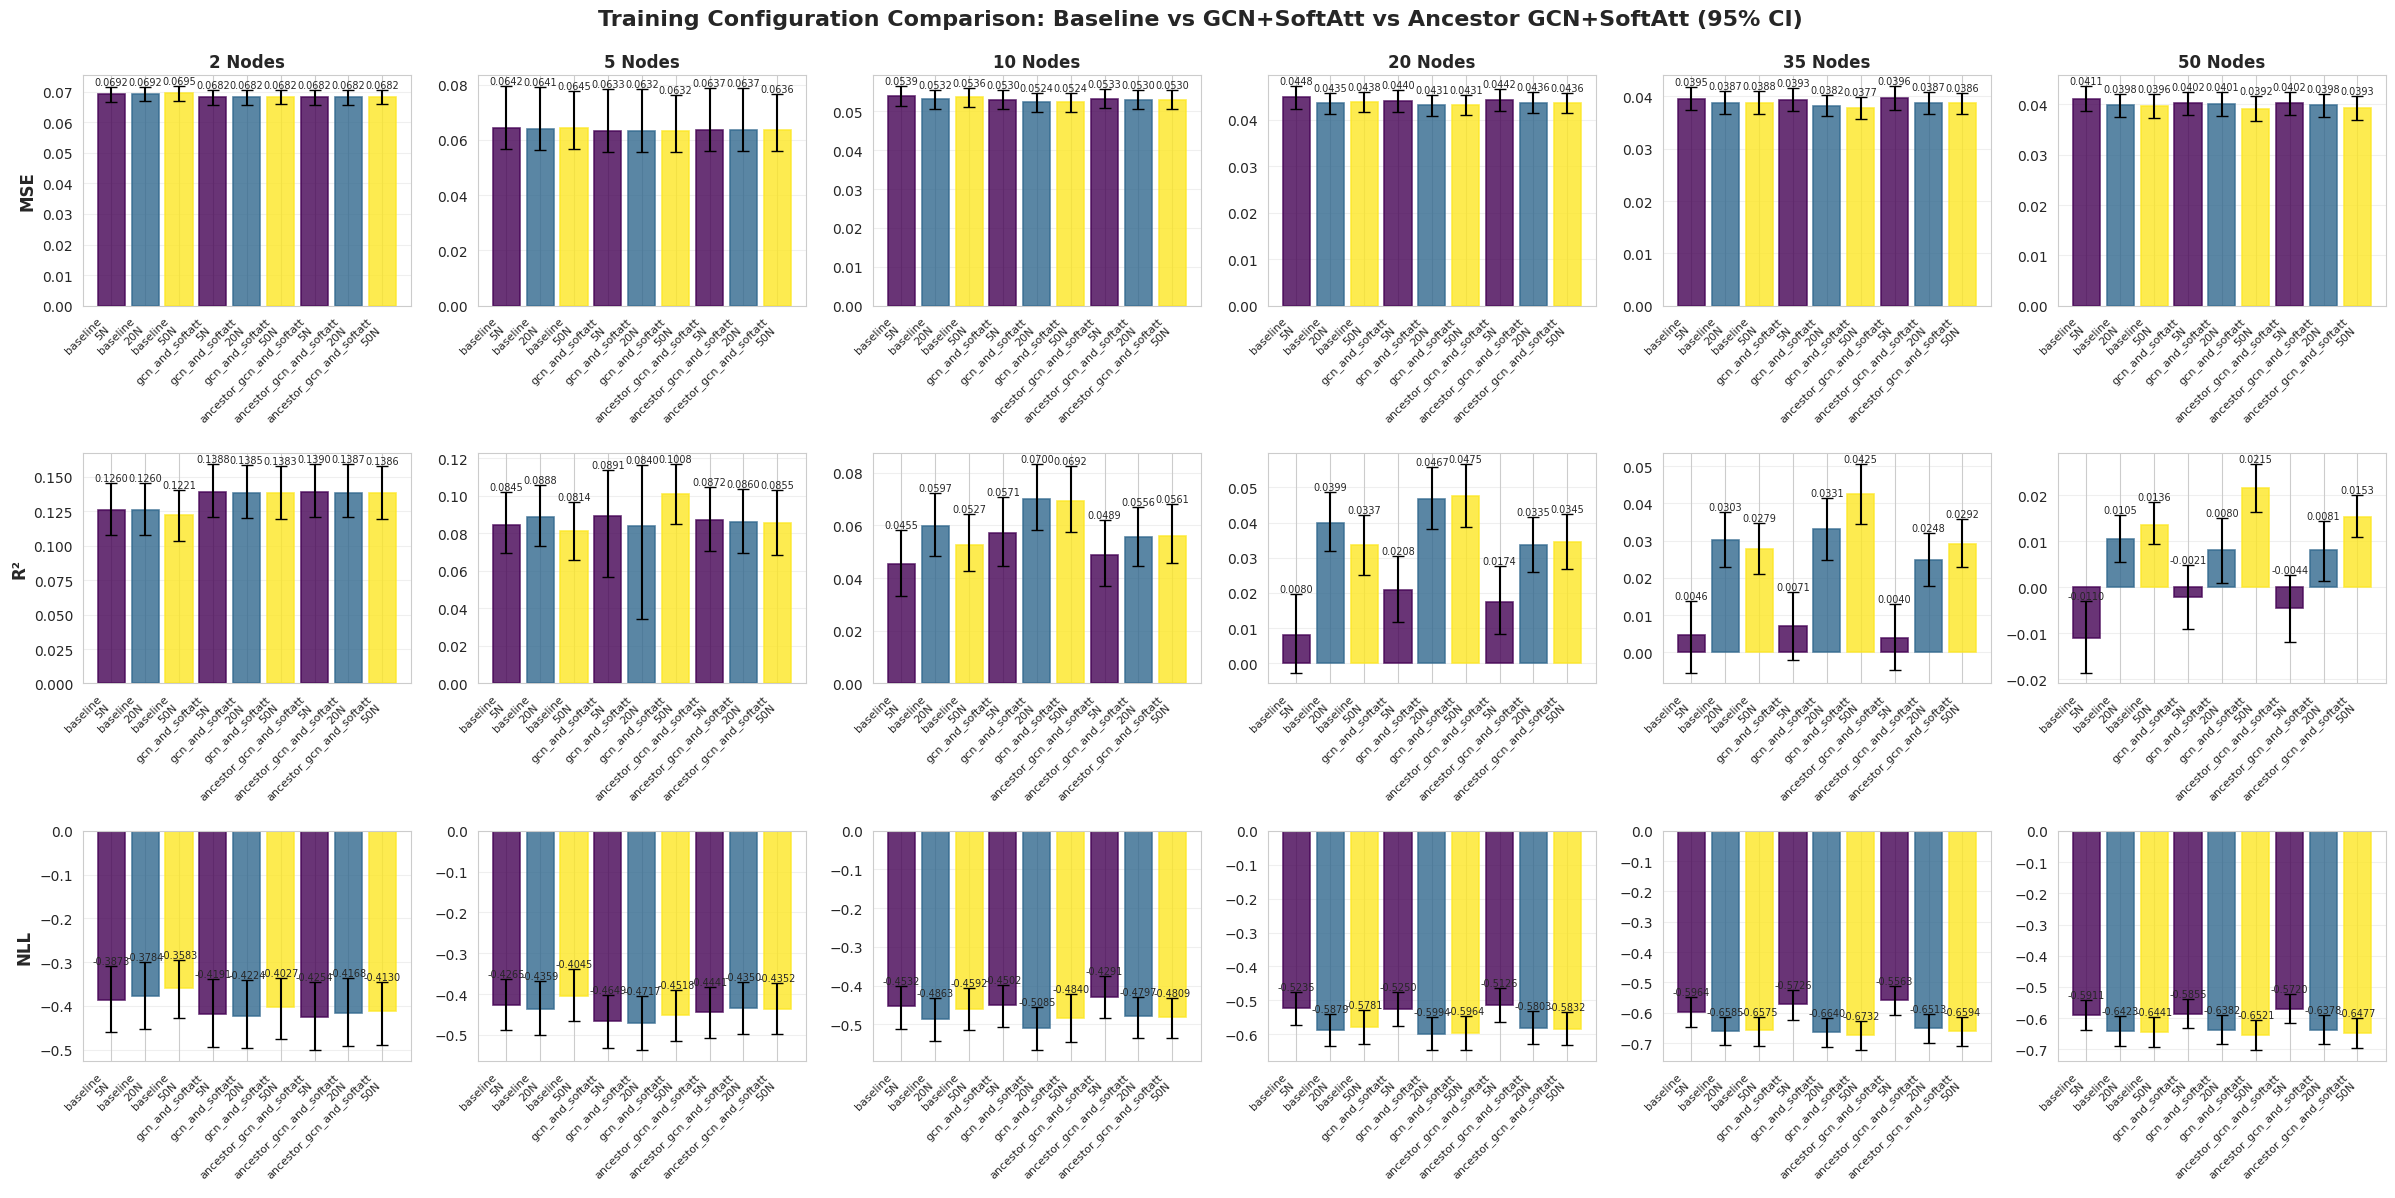

In [89]:
# Compare gcn_and_softatt, ancestor_gcn_and_softatt, and baseline models across training configurations
def plot_training_config_comparison(df_5node, df_20node, df_50node):
    """Compare specific models across different training configurations."""
    
    # Select models to compare (including ancestor models)
    models_to_compare = ['baseline', 'gcn_and_softatt', 'ancestor_gcn_and_softatt']
    node_counts = [2, 5, 10, 20, 35, 50]
    metrics = ['mse', 'r2', 'nll']
    metric_titles = ['MSE', 'R²', 'NLL']
    
    # Training configurations
    configs = {
        '5-Node Training': df_5node,
        '20-Node Training': df_20node,
        '50-Node Training': df_50node
    }
    
    # Color scheme for training configs
    config_colors = {
        '5-Node Training': '#440154',
        '20-Node Training': '#31688e',
        '50-Node Training': '#fde724'
    }
    
    # Create figure with subplots: 3 metrics x 6 node counts
    fig, axes = plt.subplots(len(metrics), len(node_counts), figsize=(24, 12))
    
    for metric_idx, (metric, metric_title) in enumerate(zip(metrics, metric_titles)):
        for node_idx, node_count in enumerate(node_counts):
            ax = axes[metric_idx, node_idx]
            
            # Collect data for each training config and model
            bar_data = []
            bar_labels = []
            bar_colors = []
            yerr_data = []
            
            for model in models_to_compare:
                for config_name, df in configs.items():
                    # Filter data
                    data = df[(df['model'] == model) & (df['node_count'] == node_count)]
                    
                    if len(data) > 0:
                        metric_col = f'{metric}_mean'
                        ci_lower_col = f'{metric}_mean_ci_lower'
                        ci_upper_col = f'{metric}_mean_ci_upper'
                        
                        value = data[metric_col].values[0]
                        bar_data.append(value)
                        
                        # Create label
                        label = f"{model}\n{config_name.split('-')[0]}N"
                        bar_labels.append(label)
                        bar_colors.append(config_colors[config_name])
                        
                        # Calculate error bars
                        if ci_lower_col in data.columns and ci_upper_col in data.columns:
                            ci_lower = data[ci_lower_col].values[0]
                            ci_upper = data[ci_upper_col].values[0]
                            yerr_lower = value - ci_lower
                            yerr_upper = ci_upper - value
                            yerr_data.append([yerr_lower, yerr_upper])
                        else:
                            yerr_data.append([0, 0])
            
            if bar_data:
                x_pos = np.arange(len(bar_data))
                yerr_array = np.array(yerr_data).T
                
                bars = ax.bar(x_pos, bar_data, yerr=yerr_array, capsize=4, 
                            alpha=0.8, edgecolor='black', linewidth=1.2)
                
                # Color bars
                for bar, color in zip(bars, bar_colors):
                    bar.set_color(color)
                
                # Add value labels
                for i, val in enumerate(bar_data):
                    label_y = val + yerr_array[1][i]
                    ax.text(i, label_y, f'{val:.4f}', ha='center', va='bottom', 
                           fontsize=7, rotation=0)
                
                ax.set_xticks(x_pos)
                ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=8)
            else:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                       transform=ax.transAxes)
            
            # Labels
            if node_idx == 0:
                ax.set_ylabel(metric_title, fontsize=12, fontweight='bold')
            
            if metric_idx == 0:
                ax.set_title(f'{node_count} Nodes', fontsize=12, fontweight='bold')
            
            ax.grid(axis='y', alpha=0.3)
    
    plt.suptitle('Training Configuration Comparison: Baseline vs GCN+SoftAtt vs Ancestor GCN+SoftAtt (95% CI)', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

# Create the comparison plot
plot_training_config_comparison(df_5node, df_20node, df_50node)